--- Step 1: Loading Dataset ---
Data Dimensions: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



--- Step 2: Exploration ---
Total missing values: 0

Class Distribution (0: Malignant, 1: Benign):
target
1    357
0    212
Name: count, dtype: int64


<Figure size 1000x800 with 0 Axes>

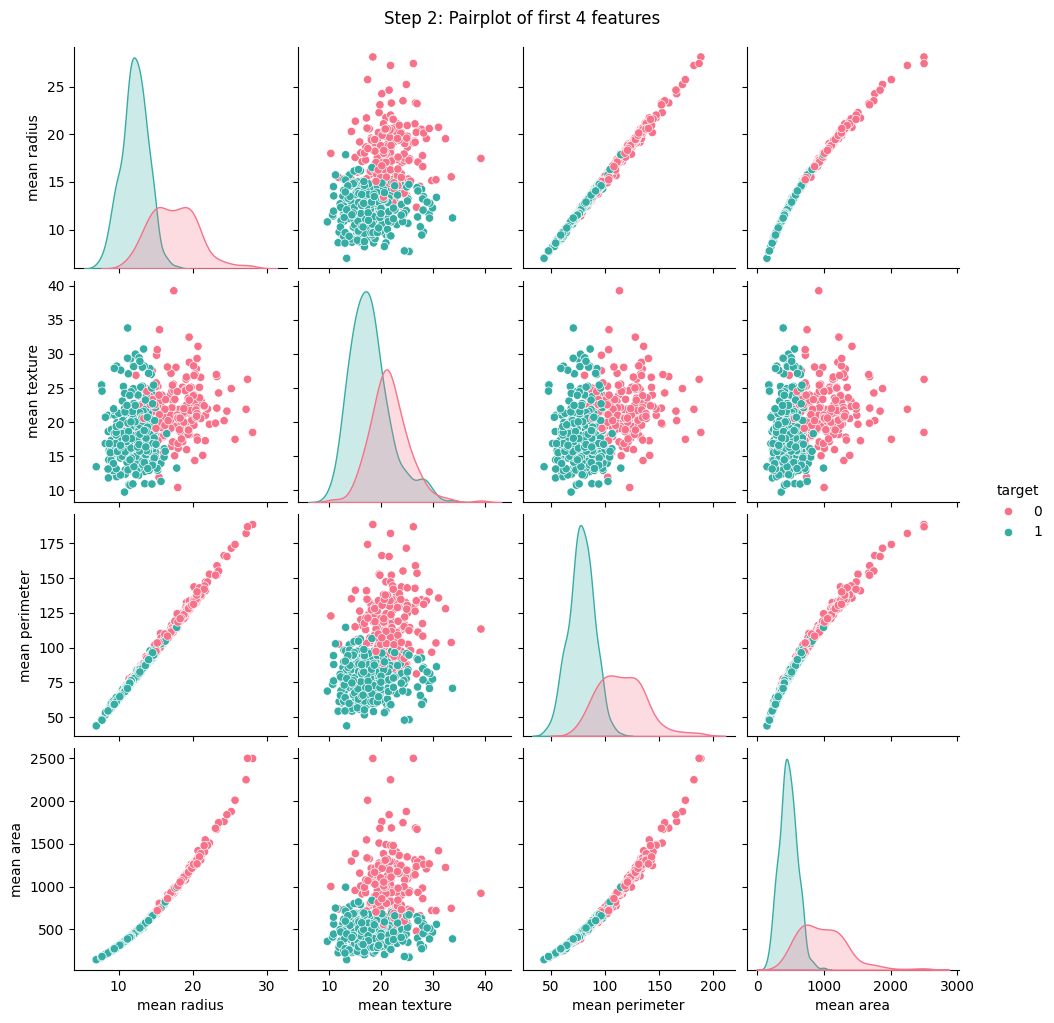

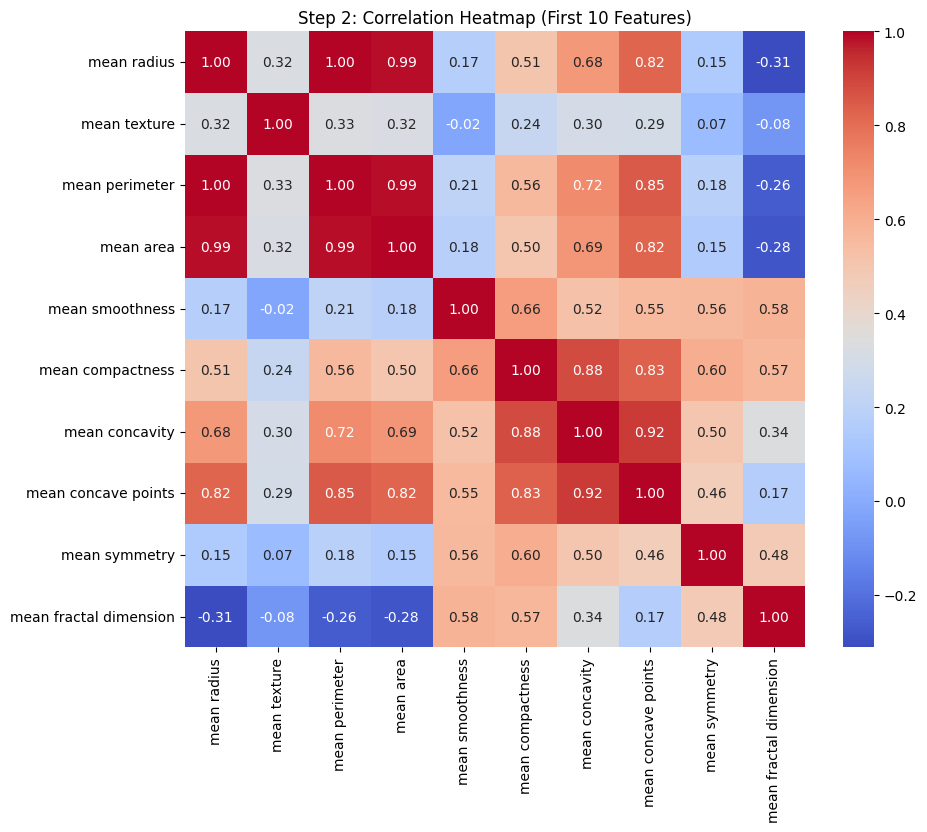


--- Step 3: Train/Test Split ---
Training set size: 455 samples
Testing set size: 114 samples

--- Step 4: Decision Tree Baseline ---


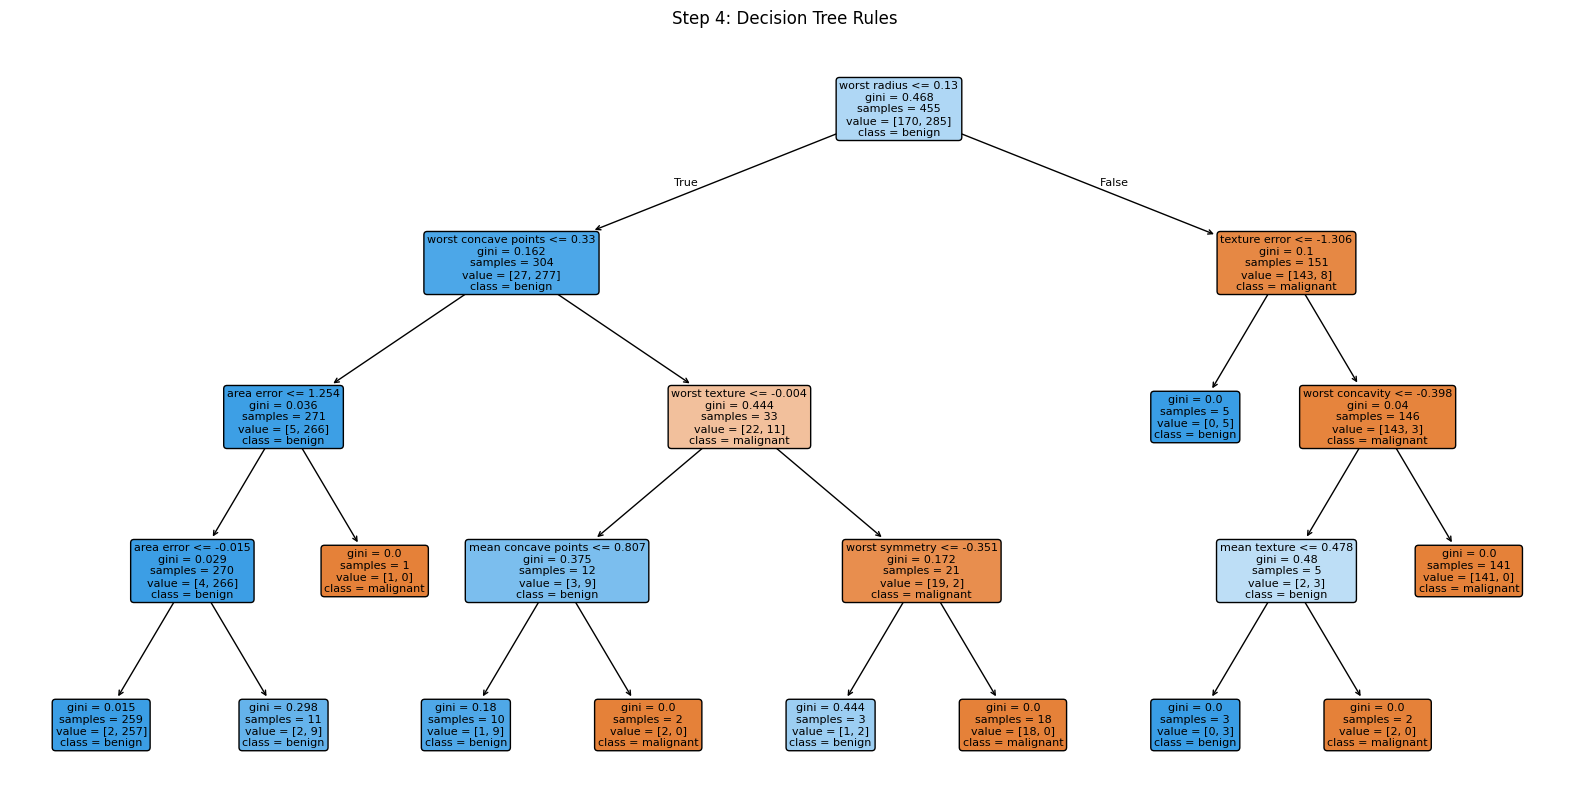


--- Step 5: Random Forest ---


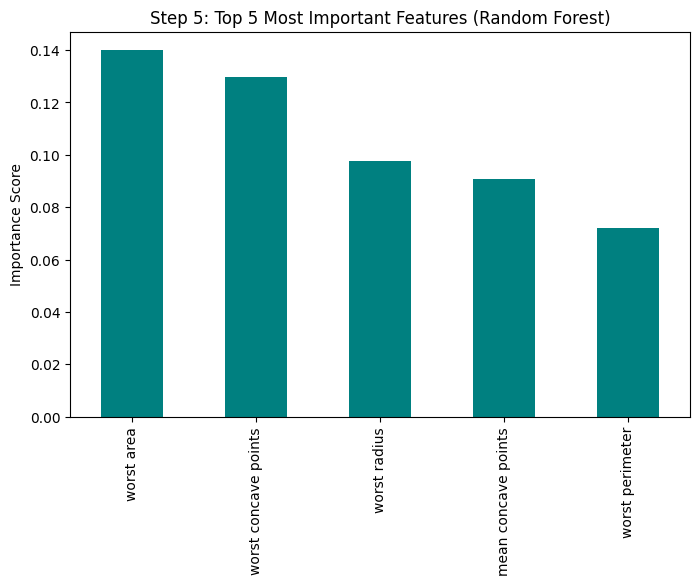


--- Step 6: XGBoost ---

--- Step 7: Model Comparison ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree (Depth 4),0.938596,0.957746,0.944444,0.951049
1,Random Forest (Default),0.956140,0.958904,0.972222,0.965517
2,Random Forest (Tuned),0.956140,0.958904,0.972222,0.965517
3,XGBoost (Default),0.956140,0.946667,0.986111,0.965986
4,XGBoost (Tuned),0.947368,0.945946,0.972222,0.958904


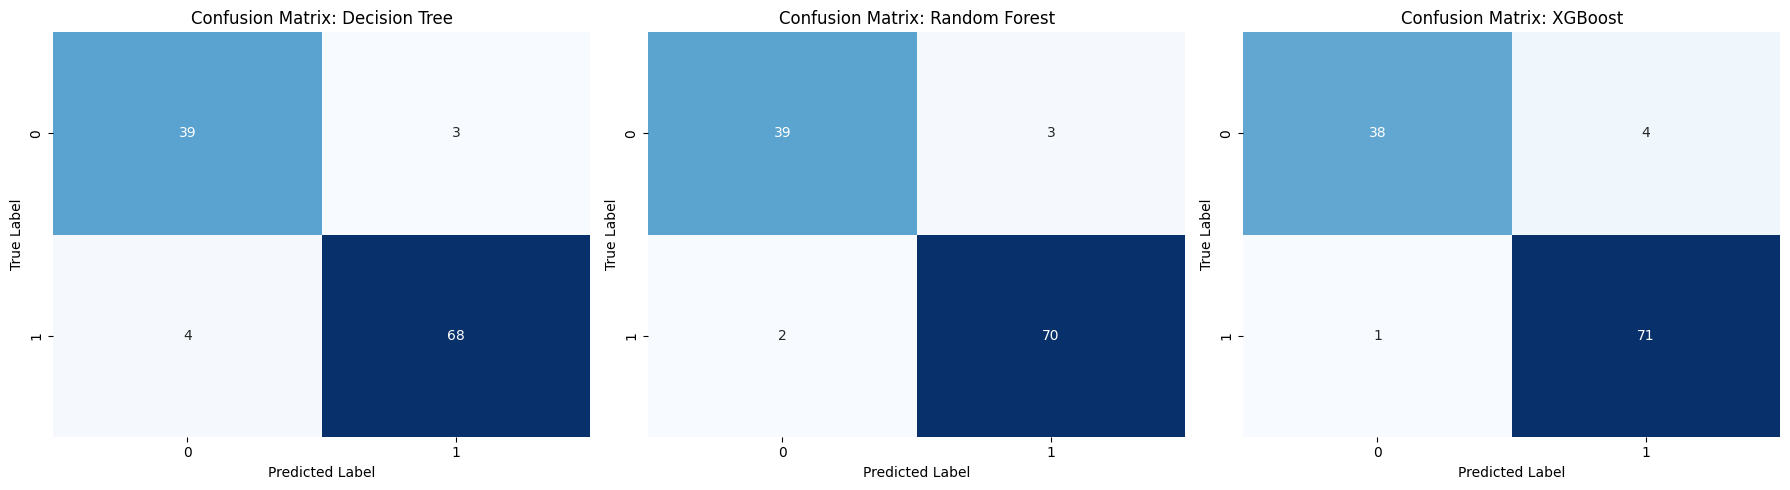

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn and XGBoost imports
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import xgboost as xgb

# ==========================================
# Step 1: Prepare the work environment
# ==========================================
print("--- Step 1: Loading Dataset ---")
cancer = load_breast_cancer()
# Create DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
# Add target column (0 = malignant, 1 = benign)
df['target'] = cancer.target

print(f"Data Dimensions: {df.shape}")
display(df.head())

# ==========================================
# Step 2: Explore the dataset
# ==========================================
print("\n--- Step 2: Exploration ---")
print(f"Total missing values: {df.isnull().sum().sum()}")
print("\nClass Distribution (0: Malignant, 1: Benign):")
print(df['target'].value_counts())

# Visualize relationships between the first 4 features
plt.figure(figsize=(10, 8))
sns.pairplot(df, vars=cancer.feature_names[:4], hue='target', palette='husl')
plt.suptitle("Step 2: Pairplot of first 4 features", y=1.02)
plt.show()

# Correlation Heatmap for the first 10 mean features
plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :10].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Step 2: Correlation Heatmap (First 10 Features)")
plt.show()

# ==========================================
# Step 3: Set up validation
# ==========================================
print("\n--- Step 3: Train/Test Split ---")
X = df.drop('target', axis=1)
y = df['target']

# 80/20 split, stratify ensures the 0/1 ratio remains the same in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scaling is highly recommended for many ML algorithms
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# ==========================================
# Step 4: Establish a baseline model (Decision Tree)
# ==========================================
print("\n--- Step 4: Decision Tree Baseline ---")
dt = DecisionTreeClassifier(random_state=42, max_depth=4)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

# Plot Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=cancer.feature_names, class_names=cancer.target_names, filled=True, rounded=True)
plt.title("Step 4: Decision Tree Rules")
plt.show()

# ==========================================
# Step 5: Improve performance (Random Forest)
# ==========================================
print("\n--- Step 5: Random Forest ---")
# Default RF
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train_scaled, y_train)
y_pred_rf = rf_default.predict(X_test_scaled)

# Tuned RF (Example configs)
rf_tuned = RandomForestClassifier(n_estimators=50, max_depth=5, min_samples_leaf=2, random_state=42)
rf_tuned.fit(X_train_scaled, y_train)
y_pred_rf_tuned = rf_tuned.predict(X_test_scaled)

# Feature Importance
importances_rf = pd.Series(rf_default.feature_importances_, index=cancer.feature_names).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances_rf.head(5).plot(kind='bar', color='teal')
plt.title("Step 5: Top 5 Most Important Features (Random Forest)")
plt.ylabel("Importance Score")
plt.show()

# ==========================================
# Step 6: Explore a more advanced model (XGBoost)
# ==========================================
print("\n--- Step 6: XGBoost ---")
# Default XGBoost
xgb_default = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_default.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_default.predict(X_test_scaled)

# Tuned XGBoost (Adjusting learning rate and max depth)
xgb_tuned = xgb.XGBClassifier(learning_rate=0.05, max_depth=3, n_estimators=150, random_state=42, eval_metric='logloss')
xgb_tuned.fit(X_train_scaled, y_train)
y_pred_xgb_tuned = xgb_tuned.predict(X_test_scaled)

# ==========================================
# Step 7: Compare and interpret
# ==========================================
print("\n--- Step 7: Model Comparison ---")

def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

metrics_list = [
    get_metrics(y_test, y_pred_dt, "Decision Tree (Depth 4)"),
    get_metrics(y_test, y_pred_rf, "Random Forest (Default)"),
    get_metrics(y_test, y_pred_rf_tuned, "Random Forest (Tuned)"),
    get_metrics(y_test, y_pred_xgb, "XGBoost (Default)"),
    get_metrics(y_test, y_pred_xgb_tuned, "XGBoost (Tuned)")
]

df_metrics = pd.DataFrame(metrics_list)
display(df_metrics)

# Confusion Matrices for the top 3 core models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_preds = [("Decision Tree", y_pred_dt), ("Random Forest", y_pred_rf), ("XGBoost", y_pred_xgb)]

for i, (name, preds) in enumerate(models_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()